In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split

In [22]:
def load_dataset(file_path):

    if file_path.endswith(".csv"):
        df = pd.read_csv(file_path)

    elif file_path.endswith(".data"):
        columns = [
            "sepal_length",
            "sepal_width",
            "petal_length",
            "petal_width",
            "species"
        ]
        df = pd.read_csv(file_path, header=None, names=columns)

    elif file_path.endswith(".arff"):
        data, meta = arff.loadarff(file_path)
        df = pd.DataFrame(data)

        for col in df.select_dtypes([object]).columns:
            try:
                df[col] = df[col].str.decode("utf-8")
            except:
                pass

    else:
        print("Unsupported File")
        return None

    df.dropna(how="all", inplace=True)

    return df

df=load_dataset("/home/mtech2/Desktop/ML_Lab/iris/iris.data")


In [23]:
def basic_info(df):

    print("="*60)
    print("DATASET INFORMATION")
    print("="*60)

    print("\nShape")
    print(df.shape)

    print("\nRows :", df.shape[0])
    print("Columns :", df.shape[1])

    print("\nColumn Names")
    print(df.columns.tolist())

    print("\nData Types")
    print(df.dtypes)

    print("\nDataset Info")
    df.info()

    print("\nFirst Five Rows")
    print(df.head())

    print("\nLast Five Rows")
    print(df.tail())

basic_info(df)

DATASET INFORMATION

Shape
(150, 5)

Rows : 150
Columns : 5

Column Names
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Data Types
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

First Five Rows
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2          

In [24]:
def data_quality(df):

    print("="*60)
    print("DATA QUALITY")
    print("="*60)

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nMissing Percentage")
    print((df.isnull().sum()/len(df))*100)

    print("\nDuplicate Rows")
    print(df.duplicated().sum())

    print("\nUnique Values")
    print(df.nunique())

data_quality(df)

DATA QUALITY

Missing Values
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Missing Percentage
sepal_length    0.0
sepal_width     0.0
petal_length    0.0
petal_width     0.0
species         0.0
dtype: float64

Duplicate Rows
3

Unique Values
sepal_length    35
sepal_width     23
petal_length    43
petal_width     22
species          3
dtype: int64


In [25]:
def statistical_summary(df):

    print("="*60)
    print("STATISTICAL SUMMARY")
    print("="*60)

    print(df.describe(include="all"))

    print("\nMean")
    print(df.mean(numeric_only=True))

    print("\nMedian")
    print(df.median(numeric_only=True))

    print("\nMode")
    print(df.mode().head(1))

statistical_summary(df)

STATISTICAL SUMMARY
        sepal_length  sepal_width  petal_length  petal_width      species
count     150.000000   150.000000    150.000000   150.000000          150
unique           NaN          NaN           NaN          NaN            3
top              NaN          NaN           NaN          NaN  Iris-setosa
freq             NaN          NaN           NaN          NaN           50
mean        5.843333     3.054000      3.758667     1.198667          NaN
std         0.828066     0.433594      1.764420     0.763161          NaN
min         4.300000     2.000000      1.000000     0.100000          NaN
25%         5.100000     2.800000      1.600000     0.300000          NaN
50%         5.800000     3.000000      4.350000     1.300000          NaN
75%         6.400000     3.300000      5.100000     1.800000          NaN
max         7.900000     4.400000      6.900000     2.500000          NaN

Mean
sepal_length    5.843333
sepal_width     3.054000
petal_length    3.758667
petal_width

In [26]:
def find_outliers(df):

    numerical = df.select_dtypes(include=np.number)

    if len(numerical.columns) == 0:
        return

    print("="*60)
    print("OUTLIER ANALYSIS")
    print("="*60)

    for col in numerical.columns:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        print("\nColumn :", col)
        print("Number of Outliers :", len(outliers))

        if len(outliers) > 0:
            print(outliers[[col]])

NUMERICAL ANALYSIS

Correlation Matrix
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.109369      0.871754     0.817954
sepal_width      -0.109369     1.000000     -0.420516    -0.356544
petal_length      0.871754    -0.420516      1.000000     0.962757
petal_width       0.817954    -0.356544      0.962757     1.000000


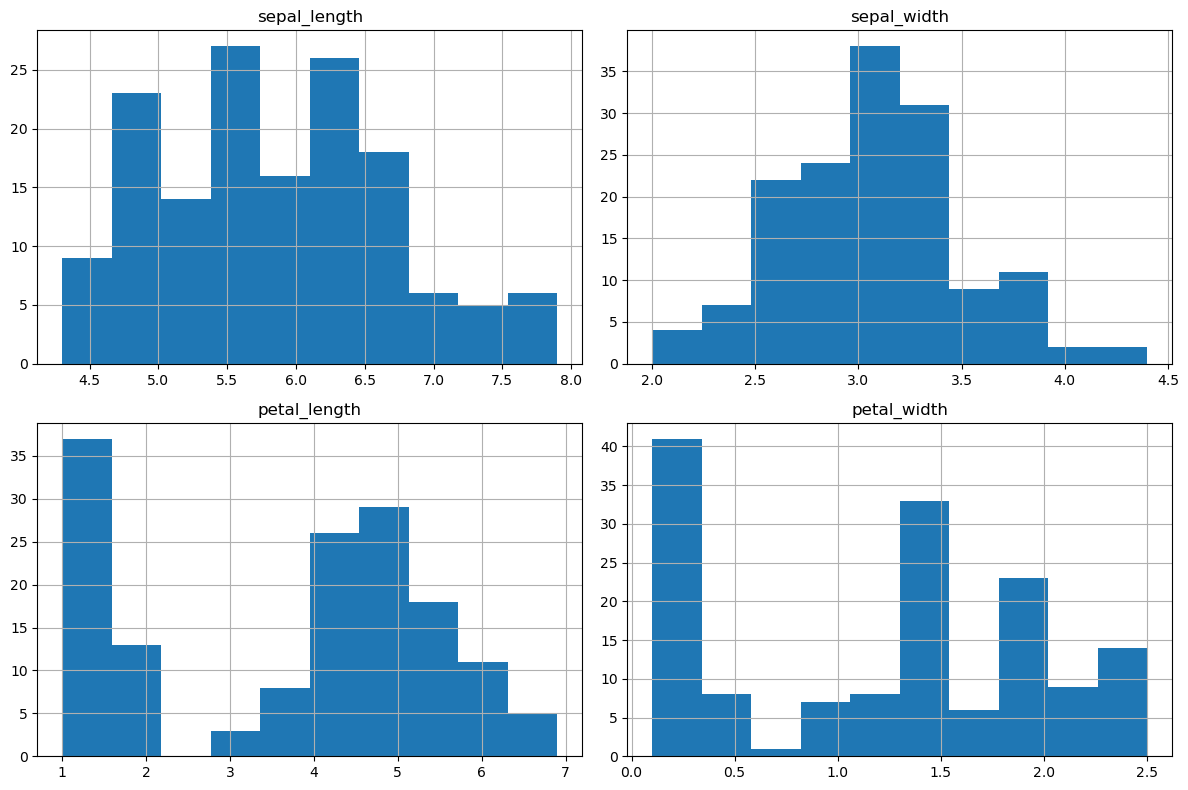

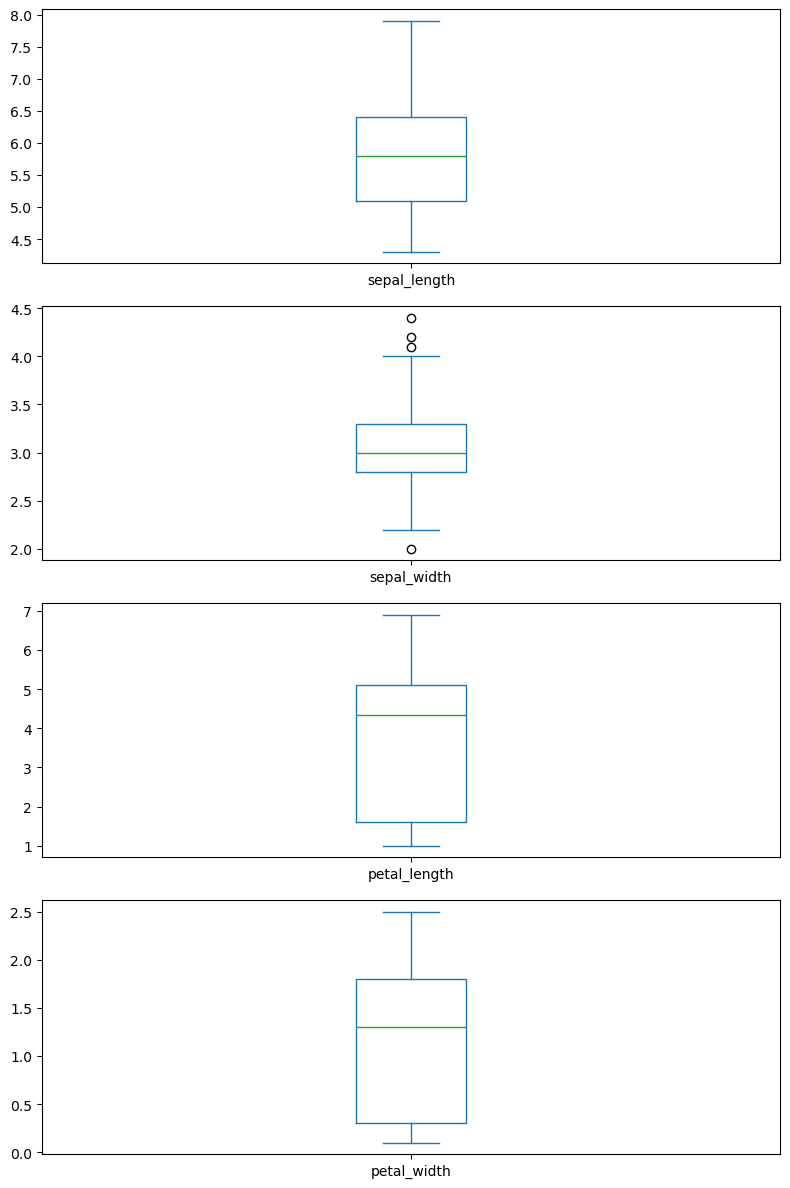

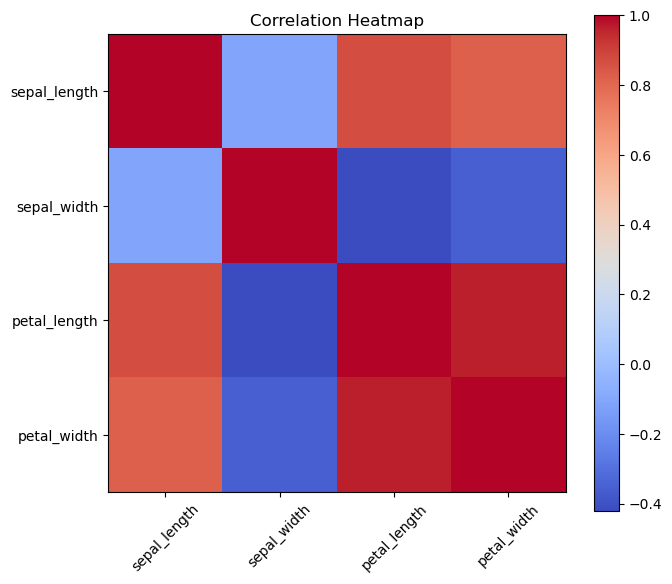

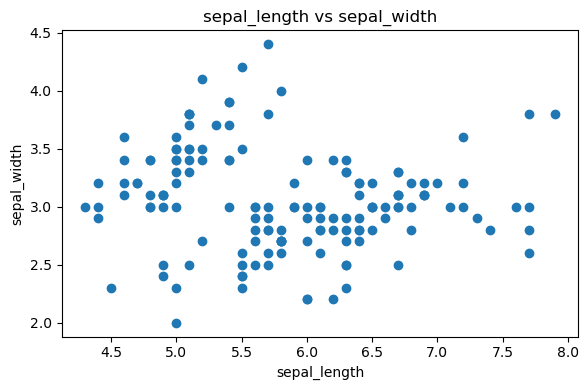

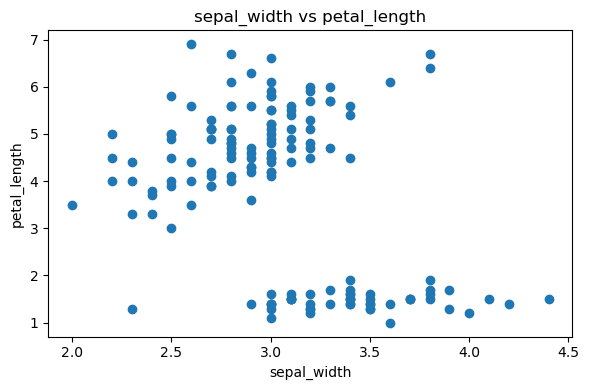

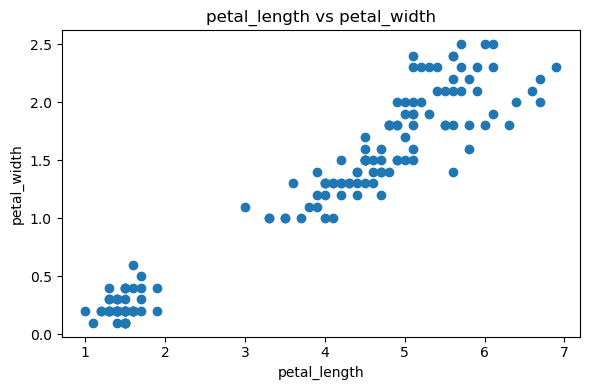

In [27]:
def numerical_analysis(df):

    numerical = df.select_dtypes(include=np.number)

    if len(numerical.columns) == 0:
        return

    if len(numerical.columns) > 10:
        plot_data = numerical.iloc[:, :10]
    else:
        plot_data = numerical

    print("="*60)
    print("NUMERICAL ANALYSIS")
    print("="*60)

    print("\nCorrelation Matrix")
    print(plot_data.corr())

    plot_data.hist(figsize=(12,8))
    plt.tight_layout()
    plt.show()

    plot_data.plot(
        kind="box",
        subplots=True,
        layout=(len(plot_data.columns),1),
        figsize=(8,3*len(plot_data.columns)),
        sharex=False
    )

    plt.tight_layout()
    plt.show()

    corr = plot_data.corr()

    plt.figure(figsize=(7,6))
    plt.imshow(corr,cmap="coolwarm")
    plt.colorbar()

    plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)
    plt.yticks(range(len(corr.columns)),corr.columns)

    plt.title("Correlation Heatmap")

    plt.tight_layout()
    plt.show()

    if len(plot_data.columns) <= 6:

        for i in range(len(plot_data.columns)-1):

            plt.figure(figsize=(6,4))

            plt.scatter(
                plot_data.iloc[:,i],
                plot_data.iloc[:,i+1]
            )

            plt.xlabel(plot_data.columns[i])
            plt.ylabel(plot_data.columns[i+1])

            plt.title(plot_data.columns[i]+" vs "+plot_data.columns[i+1])

            plt.tight_layout()
            plt.show()

numerical_analysis(df)

CATEGORICAL ANALYSIS

Column : species
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


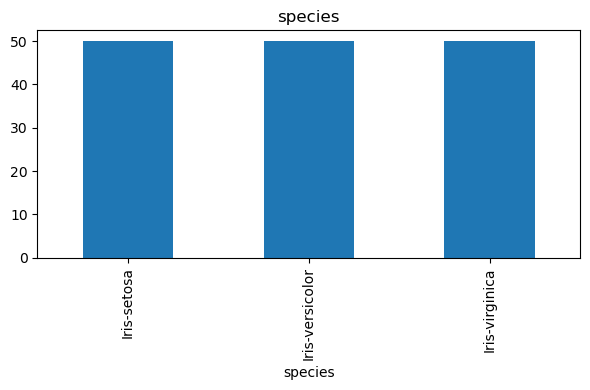

In [28]:
def categorical_analysis(df):

    categorical = df.select_dtypes(exclude=np.number)

    if len(categorical.columns) == 0:
        return

    print("="*60)
    print("CATEGORICAL ANALYSIS")
    print("="*60)

    for col in categorical.columns:

        print("\nColumn :", col)
        print(df[col].value_counts())

        df[col].value_counts().plot(
            kind="bar",
            figsize=(6,4)
        )

        plt.title(col)
        plt.tight_layout()
        plt.show()

categorical_analysis(df)

In [31]:
def final_summary(df):

    numerical = df.select_dtypes(include=np.number)
    categorical = df.select_dtypes(exclude=np.number)

    print("="*60)
    print("EDA SUMMARY")
    print("="*60)

    print("Rows :", df.shape[0])
    print("Columns :", df.shape[1])

    print("Numerical Columns :", len(numerical.columns))
    print("Categorical Columns :", len(categorical.columns))

    print("Missing Values :", df.isnull().sum().sum())

    print("Duplicate Rows :", df.duplicated().sum())

    print("\nEDA Completed Successfully")
final_summary(df)

EDA SUMMARY
Rows : 150
Columns : 5
Numerical Columns : 4
Categorical Columns : 1
Missing Values : 0
Duplicate Rows : 3

EDA Completed Successfully


Pre Processing

In [ ]:
df = df.drop_duplicates()
print("\nDuplicate Rows")
print(df.duplicated().sum())

In [ ]:

encoder = LabelEncoder()

df["species"] = encoder.fit_transform(df["species"])

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

Feature selection

In [33]:
X = df.drop("species", axis=1)

y = df["species"]

In [34]:
selector = SelectKBest(score_func=f_classif, k="all")

selector.fit(X, y)

,score_func,<function f_c...x70f3e0c04f40>
,k,'all'


In [35]:
scores = selector.scores_

print("Feature Scores")
print("-" * 40)

for feature, score in zip(X.columns, scores):
    print(feature, ":", round(score, 2))

Feature Scores
----------------------------------------
sepal_length : 119.26
sepal_width : 47.36
petal_length : 1179.03
petal_width : 959.32


In [36]:
feature_scores = {
    "Feature": X.columns,
    "Score": scores
}

feature_scores = pd.DataFrame(feature_scores)

feature_scores = feature_scores.sort_values(
    by="Score",
    ascending=False
)

print("\nFeature Ranking")
print(feature_scores)


Feature Ranking
        Feature        Score
2  petal_length  1179.034328
3   petal_width   959.324406
0  sepal_length   119.264502
1   sepal_width    47.364461


Data Splitting

In [38]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [39]:
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [40]:
print("Training Set")

print(X_train.shape)

print(y_train.shape)

print()

print("Validation Set")

print(X_validation.shape)

print(y_validation.shape)

print()

print("Testing Set")

print(X_test.shape)

print(y_test.shape)

Training Set
(105, 4)
(105,)

Validation Set
(22, 4)
(22,)

Testing Set
(23, 4)
(23,)


In [42]:
import seaborn as sns

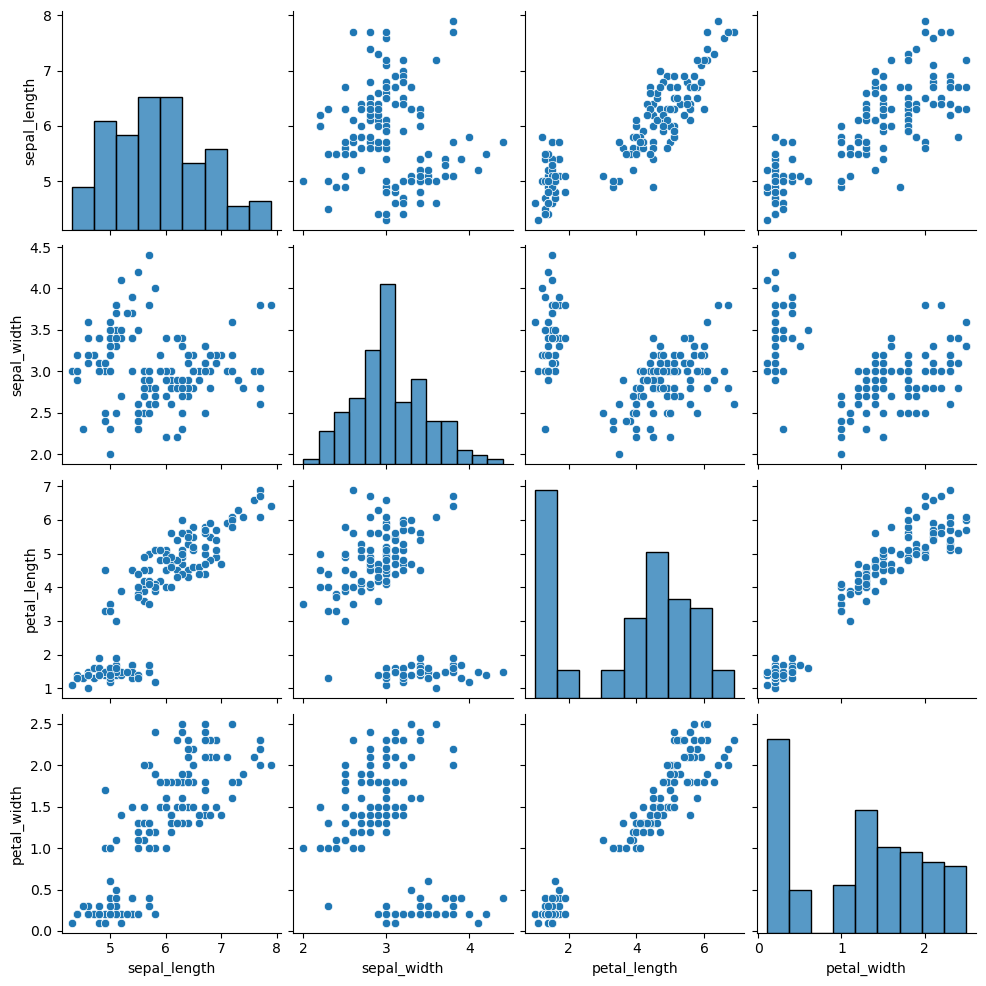

In [44]:
sns.pairplot(X)